In [1]:
# --- One-cell "run in one go" block: model + samples heat maps with identical axes & color scale ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import lgamma
from matplotlib.colors import Normalize, LogNorm, PowerNorm
from IPython.display import display
import ipywidgets as W



# ---------- I/O ----------
def _canon(s: str) -> str:
    return "".join(ch for ch in s.lower() if ch.isalnum())

def load_csv_with_headers(csv_path: str):
    """
    Expect header row with columns for time, L, mean_energy, alpha (names are matched flexibly).
    Returns 1-D arrays sorted by time: t, L, Eavg, alpha
    """
    df = pd.read_csv(csv_path)
    if df.shape[1] < 4:
        raise ValueError("CSV must have ≥ 4 columns (time, L, mean_energy, alpha).")
    canon = {_canon(c): c for c in df.columns}
    def pick(cands, fallback_idx):
        for c in cands:
            k = _canon(c)
            if k in canon: return canon[k]
        return df.columns[fallback_idx]
    time_col  = pick(["time","t"], 0)
    L_col     = pick(["l","luminosity","rate"], 1)
    Eavg_col  = pick(["meanenergy","eavg","emean","mu","averageenergy"], 2)
    alpha_col = pick(["alpha","a"], 3)

    t     = df[time_col ].to_numpy(float)
    L     = df[L_col    ].to_numpy(float)
    Eavg  = df[Eavg_col ].to_numpy(float)
    alpha = df[alpha_col].to_numpy(float)

    m = np.isfinite(t) & np.isfinite(L) & np.isfinite(Eavg) & np.isfinite(alpha)
    t, L, Eavg, alpha = t[m], L[m], Eavg[m], alpha[m]
    i = np.argsort(t)
    t, L, Eavg, alpha = t[i], L[i], Eavg[i], alpha[i]

    if np.any(alpha <= -1): raise ValueError("alpha(t) must be > -1 everywhere.")
    if np.any(Eavg  <=  0): raise ValueError("<E>(t) must be positive everywhere.")
    return t, L, Eavg, alpha

# ---------- Model pieces ----------
def gamma_pdf_E_given_t_centers(E_cent, Eavg_t_cent, alpha_t_cent):
    """
    f(E|t) for Gamma with shape k=1+alpha(t) and scale θ=Eavg(t)/k,
    evaluated on a tensor grid (E_cent[:,None], t_cent[None,:]).
    Returns array shape (len(E_cent), len(t_cent)).
    """
    E = np.asarray(E_cent, float)[:, None]                # (nE-1, 1)
    k = 1.0 + np.asarray(alpha_t_cent, float)[None, :]    # (1, nT-1)
    theta = np.asarray(Eavg_t_cent, float)[None, :] / k   # (1, nT-1)

    tiny  = np.finfo(float).tiny
    logE  = np.log(np.clip(E, tiny, None))
    logth = np.log(np.clip(theta, tiny, None))
    lgk   = np.vectorize(lgamma)(k)

    logpdf = (k - 1.0) * logE - (E / theta) - lgk - k * logth
    pdf = np.exp(logpdf)
    return np.where(E >= 0.0, pdf, 0.0)

def build_edges_and_centers(t, Eavg, alpha,
                            t_min=None, t_max=None, nt_edges=1201,
                            E_min=None, E_max=None, nE_edges=1601,
                            nsig=8.0):
    """
    Build bin edges for t and E, plus centers. If E_max not given, choose via max_t[mu + nsig*sigma].
    """
    t0, t1 = float(t[0]), float(t[-1])
    if t_min is None: t_min = t0
    if t_max is None: t_max = t1
    t_min = max(float(t_min), t0); t_max = min(float(t_max), t1)
    if not (t_min < t_max): raise ValueError("Bad time window.")

    t_edges = np.linspace(t_min, t_max, int(nt_edges))
    t_cent  = 0.5 * (t_edges[:-1] + t_edges[1:])

    # E window
    if E_min is None: E_min = 0.0
    if E_max is None:
        mu_c   = np.interp(t_cent, t, Eavg)
        a_c    = np.interp(t_cent, t, alpha)
        E_max  = float(np.max(mu_c + nsig * (mu_c / np.sqrt(1.0 + a_c))))
        E_max  = max(E_max, 10.0 * float(np.max(mu_c)), 1e-6)
    E_edges = np.linspace(float(E_min), float(E_max), int(nE_edges))
    E_cent  = 0.5 * (E_edges[:-1] + E_edges[1:])
    return (t_edges, t_cent), (E_edges, E_cent)

def model_pdf_on_centers(t, L, Eavg, alpha, t_cent, E_cent):
    """
    Compute p(E,t) = p_t(t) * f(E|t) on centers so it matches histogram2d(H) shape.
    """
    L_c   = np.interp(t_cent, t, L)
    mu_c  = np.interp(t_cent, t, Eavg)
    a_c   = np.interp(t_cent, t, alpha)
    R_c   = L_c / np.maximum(mu_c, np.finfo(float).tiny)
    Zt    = np.trapz(R_c, t_cent)
    if not np.isfinite(Zt) or Zt <= 0:
        raise ValueError("Time normalization failed: ∫ L/<E> dt must be positive.")
    p_t_c = R_c / Zt                                  # (nT-1,)
    fEt   = gamma_pdf_E_given_t_centers(E_cent, mu_c, a_c)  # (nE-1, nT-1)
    return fEt * p_t_c[None, :]

# ---------- Sampler (Scenario 1) ----------
def _time_pdf_and_icdf(t, L, Eavg, t_min=None, t_max=None, nt=4001):
    t0, t1 = float(t[0]), float(t[-1])
    if t_min is None: t_min = t0
    if t_max is None: t_max = t1
    t_min = max(t_min, t0); t_max = min(t_max, t1)
    if not (t_min < t_max): raise ValueError("Bad time window.")
    tg = np.linspace(t_min, t_max, int(nt))
    Rt = np.interp(tg, t, L) / np.maximum(np.interp(tg, t, Eavg), np.finfo(float).tiny)
    Zt = np.trapz(Rt, tg)
    pt = Rt / Zt
    cdf = np.zeros_like(tg); cdf[1:] = np.cumsum((pt[:-1] + pt[1:]) * 0.5 * np.diff(tg)); cdf /= cdf[-1]
    def sample_t(n, rng):
        u = rng.random(n)
        return np.interp(u, cdf, tg)
    return sample_t

def sample_iid_pairs(csv_path, n, t_min=None, t_max=None, seed=None):
    """
    i.i.d. samples from p(E,t): sample t via inverse-CDF on grid, then E|t via Gamma.
    """
    t, L, Eavg, alpha = load_csv_with_headers(csv_path)
    rng = np.random.default_rng(seed)
    samp_t = _time_pdf_and_icdf(t, L, Eavg, t_min=t_min, t_max=t_max)
    t_s = samp_t(n, rng)
    a   = np.interp(t_s, t, alpha)
    mu  = np.interp(t_s, t, Eavg)
    k   = 1.0 + a
    th  = mu / k
    if np.any(k <= 0) or np.any(mu <= 0): raise ValueError("alpha>-1 and <E> >0 required.")
    E_s = rng.gamma(shape=k, scale=th)
    return t_s, E_s

# ---------- One-call runner ----------
def run_pdf_and_samples_side_by_side(csv_path,
                                     # window to match your PDF plot
                                     t_min=-0.05, t_max=0.30,
                                     E_min=0.0,  E_max=30.0,
                                     # resolutions (edges)
                                     nt_edges=1201, nE_edges=1601,
                                     # samples
                                     n_samples=50_000, seed=123,
                                     # visuals
                                     cmap="plasma",
                                     same_color_scale=True,
                                     color_norm="linear",   # "linear", "log", or "power"
                                     gamma=0.5,             # only used if color_norm=="power"
                                     normalize_model_to_window=True,
                                     figsize=(12,4.8)):
    """
    Build model p(E,t) and empirical (from samples) on identical grids; plot side-by-side.
    - normalize_model_to_window=True rescales the model so ∬_window p ≈ 1 (matches empirical).
    - color_norm controls the colorbar scaling ("linear", "log", or "power" with 'gamma').
    """
    # Load data
    t, L, Eavg, alpha = load_csv_with_headers(csv_path)

    # Grids (edges + centers)
    (t_edges, t_cent), (E_edges, E_cent) = build_edges_and_centers(
        t, Eavg, alpha,
        t_min=t_min, t_max=t_max, nt_edges=nt_edges,
        E_min=E_min, E_max=E_max, nE_edges=nE_edges
    )

    # Model on centers
    Z_model = model_pdf_on_centers(t, L, Eavg, alpha, t_cent, E_cent)

    # Sample i.i.d. (Scenario 1) within time window
    t_s, E_s = sample_iid_pairs(csv_path, n=n_samples, t_min=t_min, t_max=t_max, seed=seed)

    # Restrict samples to energy window
    m = (E_s >= E_edges[0]) & (E_s <= E_edges[-1])
    t_in, E_in = t_s[m], E_s[m]
    if t_in.size == 0:
        raise ValueError("No samples fall inside the requested (t,E) window.")

    # Empirical density on the same edges (nE-1,nT-1)
    H_counts, Ee, Te = np.histogram2d(E_in, t_in, bins=[E_edges, t_edges], density=False)

    # Convert to density so sum(H*area) ≈ 1 within the window
    dE = np.diff(E_edges); dt = np.diff(t_edges)
    if not (np.allclose(dE, dE[0]) and np.allclose(dt, dt[0])):
        area = dE[:,None] * dt[None,:]; H_emp = H_counts / (t_in.size * area)
    else:
        H_emp = H_counts / (t_in.size * dE[0] * dt[0])

    # --- Normalize the model to the plotted window (optional but recommended) ---
    model_mass_window = np.sum(Z_model * dE[:,None] * dt[None,:])
    if normalize_model_to_window:
        tiny = np.finfo(float).tiny
        Z_model = Z_model / max(model_mass_window, tiny)

    # Shared color scale / color normalization
    if same_color_scale:
        vmax = float(max(Z_model.max(), H_emp.max()))
        vmin = 0.0
    else:
        vmax = vmin = None

    if color_norm == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax) if (vmax is not None) else None
    elif color_norm == "log":
        # ensure strictly positive lower bound for log scale
        eps = 1e-12 if vmax is None else max(1e-12, 1e-12 * float(vmax))
        norm = LogNorm(vmin=eps, vmax=vmax if vmax is not None else None)
    elif color_norm == "power":
        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    else:
        raise ValueError("color_norm must be 'linear', 'log', or 'power'.")

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    im0 = axes[0].pcolormesh(t_edges, E_edges, Z_model, shading="auto", cmap=cmap, norm=norm)
    axes[0].set_title("Model PDF  p(E,t)"); axes[0].set_xlabel("t"); axes[0].set_ylabel("E")
    cb0 = fig.colorbar(im0, ax=axes[0]); cb0.set_label("probability density")

    im1 = axes[1].pcolormesh(t_edges, E_edges, H_emp, shading="auto", cmap=cmap, norm=norm)
    axes[1].set_title(f"Empirical (n={n_samples:,})"); axes[1].set_xlabel("t")
    cb1 = fig.colorbar(im1, ax=axes[1]); cb1.set_label("empirical density")

    fig.tight_layout()
    plt.show()

    # Checks
    emp_total   = np.sum(H_emp * dE[:,None] * dt[None,:])
    print(f"Window: t∈[{t_edges[0]}, {t_edges[-1]}], E∈[{E_edges[0]}, {E_edges[-1]}]")
    print(f"  ∬ model density ≈ {np.sum(Z_model * dE[:,None] * dt[None,:]):.6f} "
          f"(after window-normalization)")
    print(f"  ∬ empirical density ≈ {emp_total:.6f} (should be ~1)")

    return {
        "t_edges": t_edges, "E_edges": E_edges,
        "t_cent": t_cent,   "E_cent": E_cent,
        "Z_model": Z_model, "H_empirical": H_emp,
    }


def tweak_color_scale(results,
                      cmap="plasma",
                      init_scale="linear",   # "linear", "log", "power"
                      init_gamma=0.7,        # used if scale == "power"
                      share_scale=True,      # use the same color scale for both panels
                      init_vmax=None,        # set e.g. 17.5, else auto
                      init_vmin=0.0):        # ignored for log if <=0
    Z_model = results["Z_model"]
    H_emp   = results["H_empirical"]
    t_edges = results["t_edges"]
    E_edges = results["E_edges"]

    # Defaults
    vmax_auto = float(max(Z_model.max(), H_emp.max()))
    vmax0 = float(init_vmax) if init_vmax is not None else vmax_auto
    vmin0 = float(init_vmin)

    # --- widgets ---
    scale = W.Dropdown(options=["linear", "log", "power"], value=init_scale, description="Scale")
    gamma = W.FloatSlider(value=init_gamma, min=0.1, max=3.0, step=0.05, description="γ (power)", continuous_update=False)
    share = W.Checkbox(value=share_scale, description="Share scale (both)")
    # Use a log slider for vmax (densities often span orders of magnitude)
    vmax = W.FloatLogSlider(value=max(vmax0, 1e-12), base=10, min=-12, max=np.log10(max(vmax_auto, 1e-12))*1.1,
                            step=0.02, readout_format=".3g", description="vmax", continuous_update=False)
    vmin = W.FloatLogSlider(value=max(vmin0, 1e-12), base=10, min=-12, max=np.log10(max(vmax_auto, 1e-12))-0.1,
                            step=0.02, readout_format=".3g", description="vmin", continuous_update=False)
    vmin_zero = W.Checkbox(value=True, description="vmin=0 (linear)")

    out = W.Output()

    def make_norm(kind, vmin_val, vmax_val):
        if kind == "linear":
            if vmin_zero.value:
                vmin_val = 0.0
            return Normalize(vmin=vmin_val, vmax=vmax_val)
        elif kind == "log":
            return LogNorm(vmin=max(vmin_val, 1e-12), vmax=max(vmax_val, max(vmin_val*1.001, 1e-12)))
        else:
            return PowerNorm(gamma=gamma.value, vmin=vmin_val, vmax=vmax_val)

    def update_controls(*_):
        gamma.disabled = (scale.value != "power")
        vmin.disabled  = (scale.value == "linear" and vmin_zero.value)
    update_controls()

    def redraw(*_):
        out.clear_output(wait=True)
        with out:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)

            # Build norms
            norm0 = make_norm(scale.value, vmin.value, vmax.value)
            if share.value:
                norm1 = norm0
            else:
                norm1 = make_norm(scale.value, vmin.value, vmax.value)

            im0 = axes[0].pcolormesh(t_edges, E_edges, Z_model, shading="auto", cmap=cmap, norm=norm0)
            axes[0].set_title("Model PDF  p(E,t)")
            axes[0].set_xlabel("t"); axes[0].set_ylabel("E")
            cb0 = fig.colorbar(im0, ax=axes[0]); cb0.set_label("density")

            im1 = axes[1].pcolormesh(t_edges, E_edges, H_emp, shading="auto", cmap=cmap, norm=norm1)
            axes[1].set_title("Empirical (samples)")
            axes[1].set_xlabel("t")
            cb1 = fig.colorbar(im1, ax=axes[1]); cb1.set_label("density")

            fig.tight_layout()
            plt.show()

    # wire up
    for w in (scale, gamma, vmax, vmin, vmin_zero, share):
        w.observe(lambda change: (update_controls(), redraw()), names="value")

    # initial draw
    redraw()
    display(W.VBox([W.HBox([scale, gamma, share]),
                    W.HBox([vmax, vmin, vmin_zero]),
                    out]))

# ===================== Usage (edit the path & run this cell) =====================
# Example call (matches your earlier window):
# results = run_pdf_and_samples_side_by_side(
#     csv_path="path/to/your_data.csv",
#     t_min=-0.05, t_max=0.30,
#     E_min=0.0,  E_max=30.0,
#     nt_edges=1201, nE_edges=1601,
#     n_samples=50_000, seed=123,
#     cmap="plasma", same_color_scale=True
# )

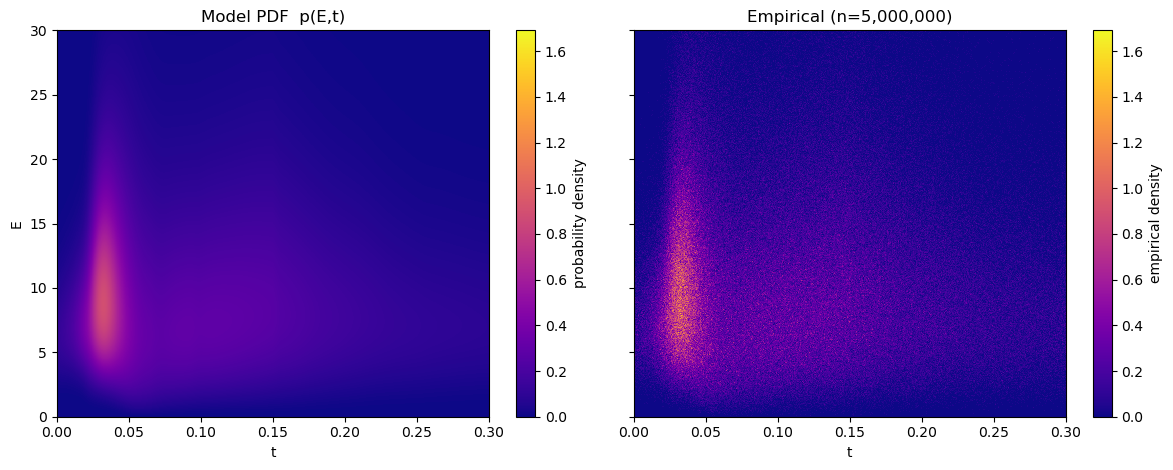

Window: t∈[0.0, 0.3], E∈[0.0, 30.0]
  ∬ model density ≈ 1.000000 (after window-normalization)
  ∬ empirical density ≈ 1.000000 (should be ~1)


In [12]:
results = run_pdf_and_samples_side_by_side(
    csv_path="Nakazato_nu_e_timeseries.csv",
    t_min=0, t_max=0.30,
    E_min=0.0,  E_max=30.0,
    nt_edges=1201, nE_edges=1601,
    n_samples=5_000_000, seed=123,
    cmap="plasma",
    color_norm="linear",
    normalize_model_to_window=True
)

In [7]:
# After you run: results = run_pdf_and_samples_side_by_side(...)

# Example: start with linear scale, and you can drag vmax from, say, 17.5 down to 1.4
tweak_color_scale(results, cmap="plasma", init_scale="linear", init_vmax=17.5)

# If you want log scaling by default:
# tweak_color_scale(results, cmap="plasma", init_scale="log")


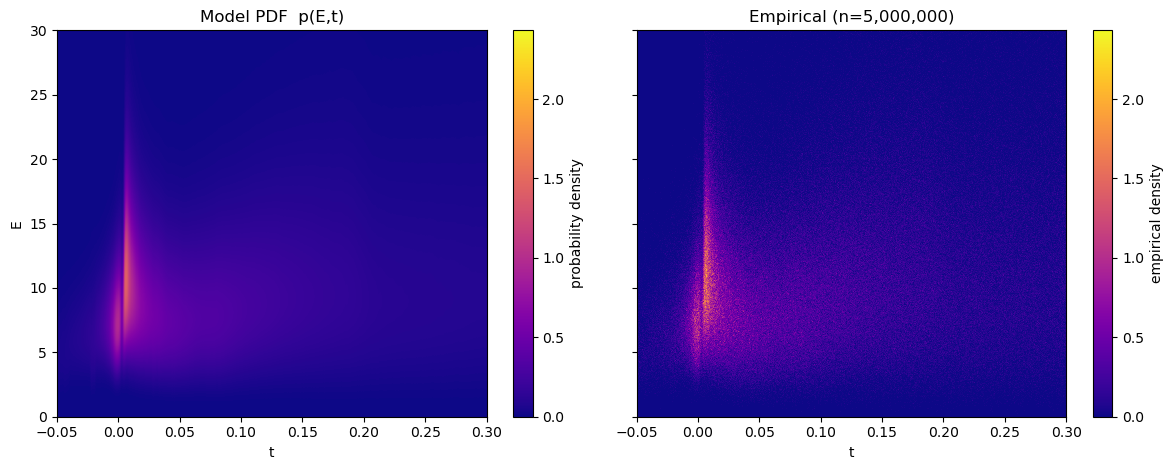

Window: t∈[-0.05, 0.3], E∈[0.0, 30.0]
  ∬ model density ≈ 1.000000 (after window-normalization)
  ∬ empirical density ≈ 1.000000 (should be ~1)


In [14]:
results = run_pdf_and_samples_side_by_side(
    csv_path="Bollig_nu_e_timeseries.csv",
    t_min=-0.05, t_max=0.30,
    E_min=0.0,  E_max=30.0,
    nt_edges=1201, nE_edges=1601,
    n_samples=5_000_000, seed=123,
    cmap="plasma",
    color_norm="linear",
    normalize_model_to_window=True
)

In [7]:
# After you run: results = run_pdf_and_samples_side_by_side(...)

# Example: start with linear scale, and you can drag vmax from, say, 17.5 down to 1.4
tweak_color_scale(results, cmap="plasma", init_scale="linear", init_vmax=17.5)

# If you want log scaling by default:
# tweak_color_scale(results, cmap="plasma", init_scale="log")